# Model Training with MLflow Tracking

**Author:** Umang Sharma  
**Roll No:** 2024AC05070  
**Date:** July 10, 2026

## Objective
Train multiple machine learning models for heart disease prediction with comprehensive MLflow tracking:
- Logistic Regression
- Random Forest Classifier
- XGBoost Classifier

## Approach
1. Load preprocessed data
2. Build scikit-learn pipelines with preprocessing
3. Implement cross-validation
4. Hyperparameter tuning with GridSearchCV
5. Log all experiments to MLflow
6. Evaluate with multiple metrics
7. Generate and save visualizations
8. Compare models and select the best one

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# XGBoost
import xgboost as xgb

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ All libraries imported successfully!")
print(f"MLflow version: {mlflow.__version__}")

✅ All libraries imported successfully!
MLflow version: 2.7.1


## 2. Configuration and Setup

In [2]:
# Project paths
PROJECT_ROOT = Path('/Users/umang.sharma/Desktop/mlops-heart-disease-project')
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
PLOTS_DIR = PROJECT_ROOT / 'reports' / 'figures'

# Create directories if they don't exist
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# MLflow setup
MLFLOW_TRACKING_URI = f"file://{PROJECT_ROOT / 'mlruns'}"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
EXPERIMENT_NAME = "heart-disease-classification"

# Create or get experiment
try:
    experiment_id = mlflow.create_experiment(
        EXPERIMENT_NAME,
        tags={
            "author": "Umang Sharma",
            "roll_no": "2024AC05070",
            "project": "Heart Disease Prediction",
            "version": "1.0"
        }
    )
    print(f"✅ Created new experiment: {EXPERIMENT_NAME}")
except:
    experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
    experiment_id = experiment.experiment_id
    print(f"✅ Using existing experiment: {EXPERIMENT_NAME}")

mlflow.set_experiment(EXPERIMENT_NAME)

# Random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"\n📁 Project Root: {PROJECT_ROOT}")
print(f"📁 Data Directory: {DATA_DIR}")
print(f"📁 Models Directory: {MODELS_DIR}")
print(f"📁 Plots Directory: {PLOTS_DIR}")
print(f"🔬 MLflow Tracking URI: {MLFLOW_TRACKING_URI}")
print(f"🧪 Experiment ID: {experiment_id}")

✅ Using existing experiment: heart-disease-classification

📁 Project Root: /Users/umang.sharma/Desktop/mlops-heart-disease-project
📁 Data Directory: /Users/umang.sharma/Desktop/mlops-heart-disease-project/data/processed
📁 Models Directory: /Users/umang.sharma/Desktop/mlops-heart-disease-project/models
📁 Plots Directory: /Users/umang.sharma/Desktop/mlops-heart-disease-project/reports/figures
🔬 MLflow Tracking URI: file:///Users/umang.sharma/Desktop/mlops-heart-disease-project/mlruns
🧪 Experiment ID: 106870266629264524


## 3. Load Preprocessed Data

In [3]:
# Load train and test datasets
X_train = pd.read_csv(DATA_DIR / 'X_train.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv').values.ravel()
y_test = pd.read_csv(DATA_DIR / 'y_test.csv').values.ravel()

print("📊 Dataset Shapes:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")

print("\n📊 Class Distribution:")
print(f"   Train - Class 0: {np.sum(y_train == 0)} ({np.sum(y_train == 0) / len(y_train) * 100:.1f}%)")
print(f"   Train - Class 1: {np.sum(y_train == 1)} ({np.sum(y_train == 1) / len(y_train) * 100:.1f}%)")
print(f"   Test - Class 0: {np.sum(y_test == 0)} ({np.sum(y_test == 0) / len(y_test) * 100:.1f}%)")
print(f"   Test - Class 1: {np.sum(y_test == 1)} ({np.sum(y_test == 1) / len(y_test) * 100:.1f}%)")

print("\n📋 Feature Names:")
print(f"   {list(X_train.columns)}")

📊 Dataset Shapes:
   X_train: (242, 13)
   X_test: (61, 13)
   y_train: (242,)
   y_test: (61,)

📊 Class Distribution:
   Train - Class 0: 131 (54.1%)
   Train - Class 1: 111 (45.9%)
   Test - Class 0: 33 (54.1%)
   Test - Class 1: 28 (45.9%)

📋 Feature Names:
   ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## 4. Helper Functions for MLflow Logging and Evaluation

In [4]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Evaluate model and return comprehensive metrics.
    
    Parameters:
    -----------
    model : trained model
    X_train, y_train : training data
    X_test, y_test : test data
    model_name : str, name of the model
    
    Returns:
    --------
    dict : dictionary of metrics
    """
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Probability predictions (for ROC-AUC)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    metrics = {
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'train_precision': precision_score(y_train, y_train_pred),
        'test_precision': precision_score(y_test, y_test_pred),
        'train_recall': recall_score(y_train, y_train_pred),
        'test_recall': recall_score(y_test, y_test_pred),
        'train_f1': f1_score(y_train, y_train_pred),
        'test_f1': f1_score(y_test, y_test_pred),
        'train_roc_auc': roc_auc_score(y_train, y_train_proba),
        'test_roc_auc': roc_auc_score(y_test, y_test_proba)
    }
    
    # Print results
    print(f"\n{'='*60}")
    print(f"📊 {model_name} - Performance Metrics")
    print(f"{'='*60}")
    print(f"\n{'Metric':<20} {'Train':>12} {'Test':>12} {'Diff':>12}")
    print(f"{'-'*60}")
    
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        train_val = metrics[f'train_{metric}']
        test_val = metrics[f'test_{metric}']
        diff = train_val - test_val
        print(f"{metric.upper():<20} {train_val:>12.4f} {test_val:>12.4f} {diff:>12.4f}")
    
    print(f"\n{'='*60}")
    
    return metrics, y_test_pred, y_test_proba


def plot_confusion_matrix(y_true, y_pred, model_name, save_path=None):
    """
    Plot confusion matrix.
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    plt.title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"   ✅ Saved confusion matrix: {save_path}")
    
    return cm


def plot_roc_curve(y_true, y_proba, model_name, save_path=None):
    """
    Plot ROC curve.
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curve - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"   ✅ Saved ROC curve: {save_path}")
    
    return fpr, tpr, roc_auc


def log_model_to_mlflow(model, model_name, params, metrics, 
                        X_train, y_train, X_test, y_test,
                        cv_scores=None):
    """
    Log model, parameters, metrics, and artifacts to MLflow.
    """
    with mlflow.start_run(run_name=model_name) as run:
        # Log parameters
        mlflow.log_params(params)
        
        # Log metrics
        mlflow.log_metrics(metrics)
        
        # Log cross-validation scores if available
        if cv_scores is not None:
            mlflow.log_metric('cv_mean_accuracy', cv_scores.mean())
            mlflow.log_metric('cv_std_accuracy', cv_scores.std())
        
        # Log model - use sklearn for all Pipeline objects
        mlflow.sklearn.log_model(model, "model")
        
        # Generate and log confusion matrix
        y_pred = model.predict(X_test)
        cm_path = PLOTS_DIR / f'{model_name.lower().replace(" ", "_")}_confusion_matrix.png'
        plot_confusion_matrix(y_test, y_pred, model_name, save_path=cm_path)
        mlflow.log_artifact(cm_path)
        plt.close()
        
        # Generate and log ROC curve
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_path = PLOTS_DIR / f'{model_name.lower().replace(" ", "_")}_roc_curve.png'
        plot_roc_curve(y_test, y_proba, model_name, save_path=roc_path)
        mlflow.log_artifact(roc_path)
        plt.close()
        
        # Log classification report as text
        report = classification_report(y_test, y_pred, 
                                       target_names=['No Disease', 'Disease'])
        report_path = PLOTS_DIR / f'{model_name.lower().replace(" ", "_")}_classification_report.txt'
        with open(report_path, 'w') as f:
            f.write(f"Classification Report - {model_name}\n")
            f.write("="*60 + "\n\n")
            f.write(report)
        mlflow.log_artifact(report_path)
        
        # Log tags
        mlflow.set_tags({
            "author": "Umang Sharma",
            "roll_no": "2024AC05070",
            "model_type": model_name,
            "framework": "scikit-learn"
        })
        
        print(f"\n   ✅ Logged {model_name} to MLflow (Run ID: {run.info.run_id})")
        
        return run.info.run_id

print("✅ Helper functions defined successfully!")

✅ Helper functions defined successfully!


## 5. Model 1: Logistic Regression with Hyperparameter Tuning

In [5]:
print("\n" + "="*80)
print("🚀 Training Model 1: Logistic Regression")
print("="*80)

# Create pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

# Define hyperparameter grid
lr_param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga']
}

# GridSearchCV with cross-validation
print("\n🔍 Performing GridSearchCV with 5-fold cross-validation...")
lr_grid_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

lr_grid_search.fit(X_train, y_train)

# Best model
lr_best_model = lr_grid_search.best_estimator_

print(f"\n✅ Best Parameters: {lr_grid_search.best_params_}")
print(f"✅ Best CV ROC-AUC Score: {lr_grid_search.best_score_:.4f}")

# Evaluate model
lr_metrics, lr_y_pred, lr_y_proba = evaluate_model(
    lr_best_model, X_train, y_train, X_test, y_test, "Logistic Regression"
)

# Cross-validation scores
lr_cv_scores = cross_val_score(
    lr_best_model, X_train, y_train, 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy'
)

print(f"\n📊 Cross-Validation Accuracy: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std():.4f})")

# Log to MLflow
lr_params = {
    'model': 'Logistic Regression',
    'C': lr_grid_search.best_params_['classifier__C'],
    'penalty': lr_grid_search.best_params_['classifier__penalty'],
    'solver': lr_grid_search.best_params_['classifier__solver'],
    'max_iter': 1000,
    'random_state': RANDOM_STATE
}

lr_run_id = log_model_to_mlflow(
    lr_best_model, "Logistic Regression", lr_params, lr_metrics,
    X_train, y_train, X_test, y_test, lr_cv_scores
)


🚀 Training Model 1: Logistic Regression

🔍 Performing GridSearchCV with 5-fold cross-validation...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Best Parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
✅ Best CV ROC-AUC Score: 0.9004

📊 Logistic Regression - Performance Metrics

Metric                      Train         Test         Diff
------------------------------------------------------------
ACCURACY                   0.8388       0.8689      -0.0300
PRECISION                  0.8600       0.8125       0.0475
RECALL                     0.7748       0.9286      -0.1538
F1                         0.8152       0.8667      -0.0515
ROC_AUC                    0.9165       0.9578      -0.0413


📊 Cross-Validation Accuracy: 0.8264 (+/- 0.0282)
   ✅ Saved confusion matrix: /Users/umang.sharma/Desktop/mlops-heart-disease-project/reports/figures/logistic_regression_confusion_matrix.png
   ✅ Saved ROC curve: /Users/umang.shar

## 6. Model 2: Random Forest with Hyperparameter Tuning

In [6]:
print("\n" + "="*80)
print("🚀 Training Model 2: Random Forest")
print("="*80)

# Create pipeline
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
])

# Define hyperparameter grid
rf_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

# GridSearchCV with cross-validation
print("\n🔍 Performing GridSearchCV with 5-fold cross-validation...")
rf_grid_search = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

rf_grid_search.fit(X_train, y_train)

# Best model
rf_best_model = rf_grid_search.best_estimator_

print(f"\n✅ Best Parameters: {rf_grid_search.best_params_}")
print(f"✅ Best CV ROC-AUC Score: {rf_grid_search.best_score_:.4f}")

# Evaluate model
rf_metrics, rf_y_pred, rf_y_proba = evaluate_model(
    rf_best_model, X_train, y_train, X_test, y_test, "Random Forest"
)

# Cross-validation scores
rf_cv_scores = cross_val_score(
    rf_best_model, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy'
)

print(f"\n📊 Cross-Validation Accuracy: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

# Log to MLflow
rf_params = {
    'model': 'Random Forest',
    'n_estimators': rf_grid_search.best_params_['classifier__n_estimators'],
    'max_depth': str(rf_grid_search.best_params_['classifier__max_depth']),
    'min_samples_split': rf_grid_search.best_params_['classifier__min_samples_split'],
    'min_samples_leaf': rf_grid_search.best_params_['classifier__min_samples_leaf'],
    'max_features': rf_grid_search.best_params_['classifier__max_features'],
    'random_state': RANDOM_STATE
}

rf_run_id = log_model_to_mlflow(
    rf_best_model, "Random Forest", rf_params, rf_metrics,
    X_train, y_train, X_test, y_test, rf_cv_scores
)


🚀 Training Model 2: Random Forest

🔍 Performing GridSearchCV with 5-fold cross-validation...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✅ Best Parameters: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
✅ Best CV ROC-AUC Score: 0.8890

📊 Random Forest - Performance Metrics

Metric                      Train         Test         Diff
------------------------------------------------------------
ACCURACY                   0.9008       0.8852       0.0156
PRECISION                  0.9485       0.8387       0.1097
RECALL                     0.8288       0.9286      -0.0997
F1                         0.8846       0.8814       0.0033
ROC_AUC                    0.9771       0.9578       0.0193


📊 Cross-Validation Accuracy: 0.8139 (+/- 0.0195)
   ✅ Saved confusion matrix: /Users/umang.sharma/Desktop/mlops-heart-disease-project/reports/figures/random_f

## 7. Model 3: XGBoost with Hyperparameter Tuning

In [7]:
print("\n" + "="*80)
print("🚀 Training Model 3: XGBoost")
print("="*80)

# Create pipeline
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
])

# Define hyperparameter grid
xgb_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7, 9],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# GridSearchCV with cross-validation
print("\n🔍 Performing GridSearchCV with 5-fold cross-validation...")
xgb_grid_search = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

xgb_grid_search.fit(X_train, y_train)

# Best model
xgb_best_model = xgb_grid_search.best_estimator_

print(f"\n✅ Best Parameters: {xgb_grid_search.best_params_}")
print(f"✅ Best CV ROC-AUC Score: {xgb_grid_search.best_score_:.4f}")

# Evaluate model
xgb_metrics, xgb_y_pred, xgb_y_proba = evaluate_model(
    xgb_best_model, X_train, y_train, X_test, y_test, "XGBoost"
)

# Cross-validation scores
xgb_cv_scores = cross_val_score(
    xgb_best_model, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy'
)

print(f"\n📊 Cross-Validation Accuracy: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std():.4f})")

# Log to MLflow
xgb_params = {
    'model': 'XGBoost',
    'n_estimators': xgb_grid_search.best_params_['classifier__n_estimators'],
    'max_depth': xgb_grid_search.best_params_['classifier__max_depth'],
    'learning_rate': xgb_grid_search.best_params_['classifier__learning_rate'],
    'subsample': xgb_grid_search.best_params_['classifier__subsample'],
    'colsample_bytree': xgb_grid_search.best_params_['classifier__colsample_bytree'],
    'random_state': RANDOM_STATE
}

xgb_run_id = log_model_to_mlflow(
    xgb_best_model, "XGBoost", xgb_params, xgb_metrics,
    X_train, y_train, X_test, y_test, xgb_cv_scores
)


🚀 Training Model 3: XGBoost

🔍 Performing GridSearchCV with 5-fold cross-validation...
Fitting 5 folds for each of 768 candidates, totalling 3840 fits

✅ Best Parameters: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 50, 'classifier__subsample': 0.7}
✅ Best CV ROC-AUC Score: 0.8862

📊 XGBoost - Performance Metrics

Metric                      Train         Test         Diff
------------------------------------------------------------
ACCURACY                   0.9421       0.8689       0.0733
PRECISION                  0.9709       0.8333       0.1375
RECALL                     0.9009       0.8929       0.0080
F1                         0.9346       0.8621       0.0725
ROC_AUC                    0.9904       0.9416       0.0489


📊 Cross-Validation Accuracy: 0.8345 (+/- 0.0326)
   ✅ Saved confusion matrix: /Users/umang.sharma/Desktop/mlops-heart-disease-project/reports/figures/xgboost_confusion_matrix.p

## 8. Model Comparison and Best Model Selection

In [8]:
print("\n" + "="*80)
print("📊 MODEL COMPARISON SUMMARY")
print("="*80)

# Create comparison dataframe
comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Test Accuracy': [
        lr_metrics['test_accuracy'],
        rf_metrics['test_accuracy'],
        xgb_metrics['test_accuracy']
    ],
    'Test Precision': [
        lr_metrics['test_precision'],
        rf_metrics['test_precision'],
        xgb_metrics['test_precision']
    ],
    'Test Recall': [
        lr_metrics['test_recall'],
        rf_metrics['test_recall'],
        xgb_metrics['test_recall']
    ],
    'Test F1': [
        lr_metrics['test_f1'],
        rf_metrics['test_f1'],
        xgb_metrics['test_f1']
    ],
    'Test ROC-AUC': [
        lr_metrics['test_roc_auc'],
        rf_metrics['test_roc_auc'],
        xgb_metrics['test_roc_auc']
    ],
    'CV Accuracy Mean': [
        lr_cv_scores.mean(),
        rf_cv_scores.mean(),
        xgb_cv_scores.mean()
    ],
    'CV Accuracy Std': [
        lr_cv_scores.std(),
        rf_cv_scores.std(),
        xgb_cv_scores.std()
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Save comparison table
comparison_path = PROJECT_ROOT / 'reports' / 'model_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f"\n✅ Saved comparison table: {comparison_path}")

# Determine best model based on test ROC-AUC
best_idx = comparison_df['Test ROC-AUC'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_roc_auc = comparison_df.loc[best_idx, 'Test ROC-AUC']

print(f"\n{'='*80}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"🏆 Test ROC-AUC: {best_roc_auc:.4f}")
print(f"{'='*80}")

# Select best model
if best_model_name == 'Logistic Regression':
    best_model = lr_best_model
    best_run_id = lr_run_id
elif best_model_name == 'Random Forest':
    best_model = rf_best_model
    best_run_id = rf_run_id
else:
    best_model = xgb_best_model
    best_run_id = xgb_run_id

print(f"\n✅ Best Model Run ID: {best_run_id}")


📊 MODEL COMPARISON SUMMARY

              Model  Test Accuracy  Test Precision  Test Recall  Test F1  Test ROC-AUC  CV Accuracy Mean  CV Accuracy Std
Logistic Regression       0.868852        0.812500     0.928571 0.866667      0.957792          0.826361         0.028214
      Random Forest       0.885246        0.838710     0.928571 0.881356      0.957792          0.813946         0.019461
            XGBoost       0.868852        0.833333     0.892857 0.862069      0.941558          0.834524         0.032640

✅ Saved comparison table: /Users/umang.sharma/Desktop/mlops-heart-disease-project/reports/model_comparison.csv

🏆 BEST MODEL: Logistic Regression
🏆 Test ROC-AUC: 0.9578

✅ Best Model Run ID: 29d25e8cb98344bcb5535b501395e272


## 9. Visualize Model Comparison


✅ Saved comparison plot: /Users/umang.sharma/Desktop/mlops-heart-disease-project/reports/figures/model_comparison.png


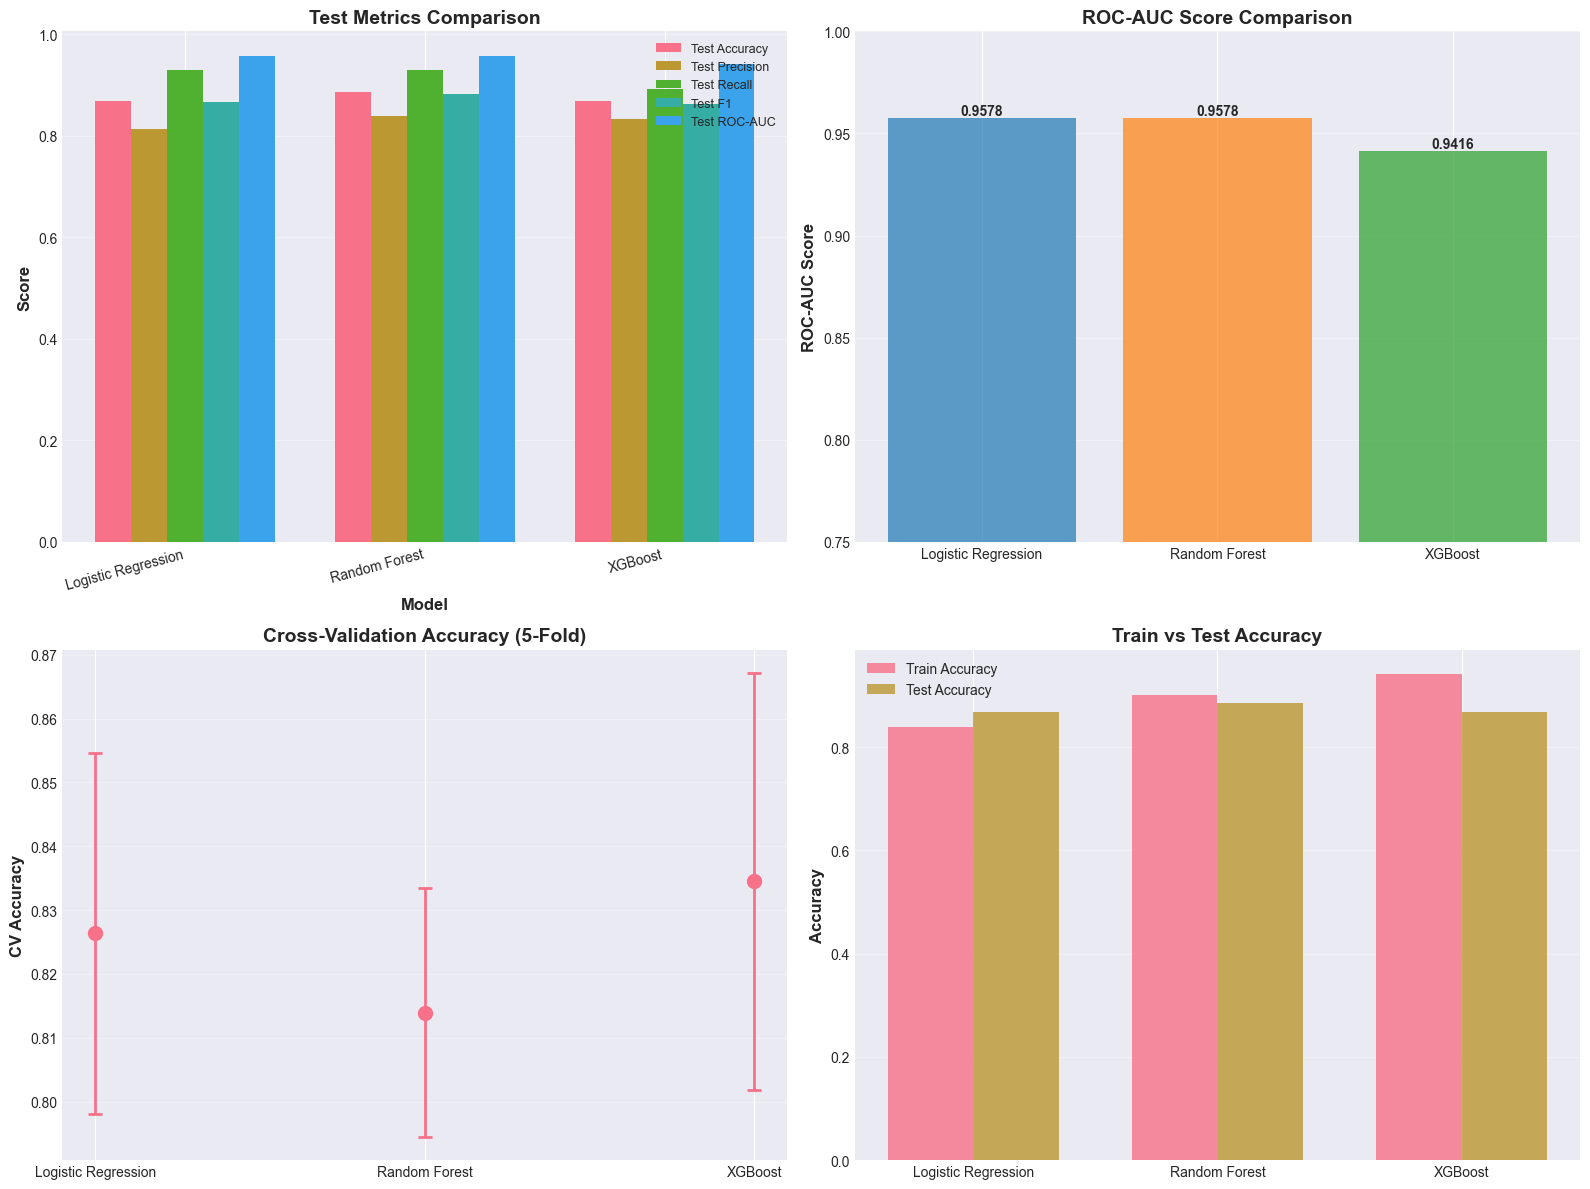

In [9]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Test Metrics Comparison
metrics_to_plot = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test ROC-AUC']
x_pos = np.arange(len(comparison_df))
width = 0.15

ax = axes[0, 0]
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x_pos + i * width, comparison_df[metric], width, label=metric)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Test Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos + width * 2)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Plot 2: ROC-AUC Comparison
ax = axes[0, 1]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = ax.bar(comparison_df['Model'], comparison_df['Test ROC-AUC'], color=colors, alpha=0.7)
ax.set_ylabel('ROC-AUC Score', fontsize=12, fontweight='bold')
ax.set_title('ROC-AUC Score Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0.75, 1.0])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Cross-Validation Accuracy with Error Bars
ax = axes[1, 0]
ax.errorbar(comparison_df['Model'], comparison_df['CV Accuracy Mean'],
            yerr=comparison_df['CV Accuracy Std'],
            fmt='o', markersize=10, capsize=5, capthick=2, linewidth=2)
ax.set_ylabel('CV Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Cross-Validation Accuracy (5-Fold)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 4: Train vs Test Accuracy
ax = axes[1, 1]
train_acc = [lr_metrics['train_accuracy'], rf_metrics['train_accuracy'], xgb_metrics['train_accuracy']]
test_acc = [lr_metrics['test_accuracy'], rf_metrics['test_accuracy'], xgb_metrics['test_accuracy']]

x = np.arange(len(comparison_df['Model']))
width = 0.35
ax.bar(x - width/2, train_acc, width, label='Train Accuracy', alpha=0.8)
ax.bar(x + width/2, test_acc, width, label='Test Accuracy', alpha=0.8)
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Train vs Test Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
comparison_plot_path = PLOTS_DIR / 'model_comparison.png'
plt.savefig(comparison_plot_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Saved comparison plot: {comparison_plot_path}")
plt.show()

## 10. Compare ROC Curves


✅ Saved ROC comparison plot: /Users/umang.sharma/Desktop/mlops-heart-disease-project/reports/figures/roc_curves_comparison.png


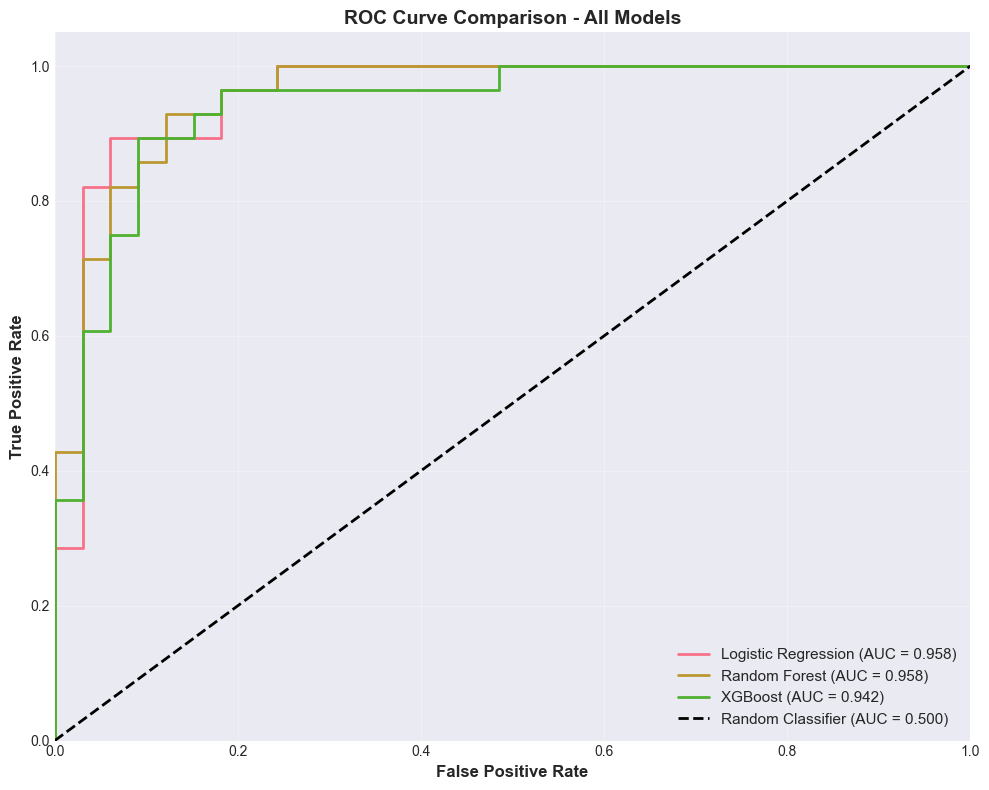

In [10]:
# Plot ROC curves for all models on same plot
plt.figure(figsize=(10, 8))

# Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_y_proba)
lr_auc = auc(lr_fpr, lr_tpr)
plt.plot(lr_fpr, lr_tpr, lw=2, label=f'Logistic Regression (AUC = {lr_auc:.3f})')

# Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_y_proba)
rf_auc = auc(rf_fpr, rf_tpr)
plt.plot(rf_fpr, rf_tpr, lw=2, label=f'Random Forest (AUC = {rf_auc:.3f})')

# XGBoost
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_y_proba)
xgb_auc = auc(xgb_fpr, xgb_tpr)
plt.plot(xgb_fpr, xgb_tpr, lw=2, label=f'XGBoost (AUC = {xgb_auc:.3f})')

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve Comparison - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

roc_comparison_path = PLOTS_DIR / 'roc_curves_comparison.png'
plt.savefig(roc_comparison_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Saved ROC comparison plot: {roc_comparison_path}")
plt.show()

## 11. Feature Importance Analysis (for tree-based models)


✅ Saved feature importance plot: /Users/umang.sharma/Desktop/mlops-heart-disease-project/reports/figures/feature_importance.png


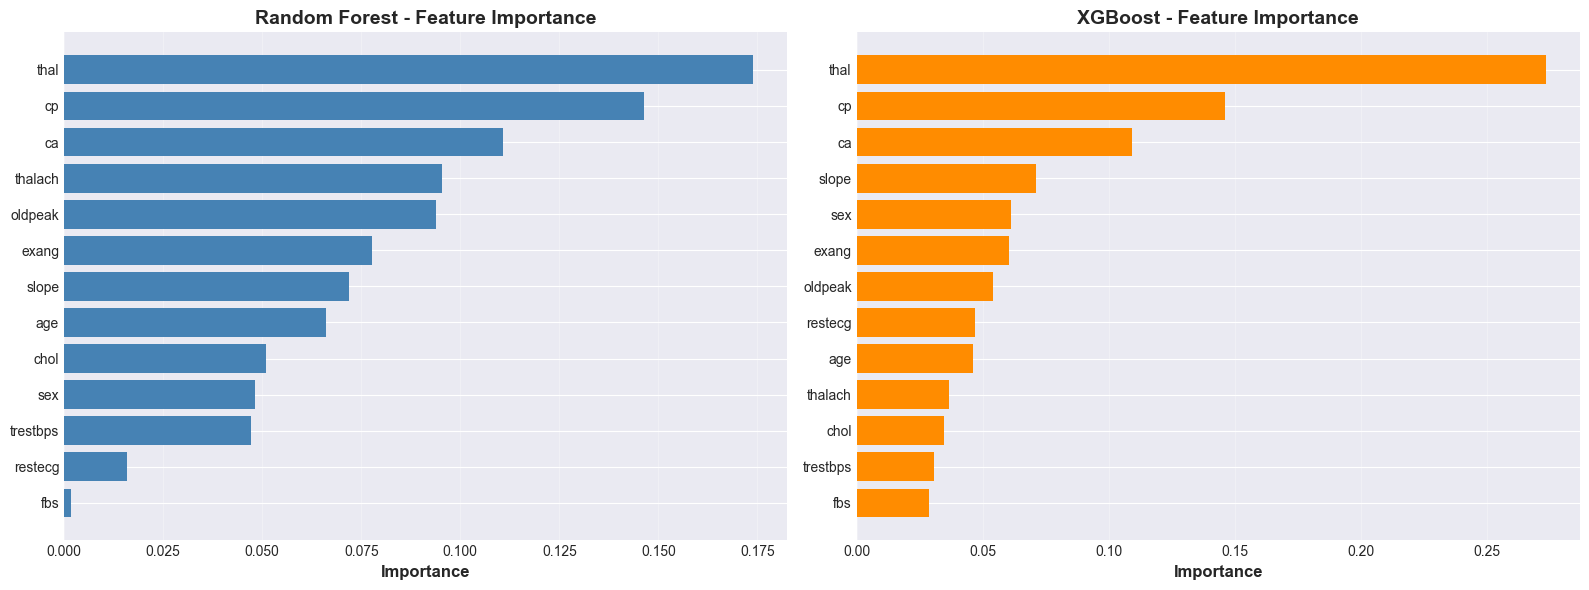


🔍 TOP 5 MOST IMPORTANT FEATURES

Random Forest:
feature  importance
   thal    0.173914
     cp    0.146468
     ca    0.110831
thalach    0.095427
oldpeak    0.093980

XGBoost:
feature  importance
   thal    0.273411
     cp    0.146142
     ca    0.109264
  slope    0.071293
    sex    0.061380


In [11]:
# Get feature importances from Random Forest and XGBoost
feature_names = X_train.columns

# Random Forest feature importance
rf_importance = rf_best_model.named_steps['classifier'].feature_importances_
rf_feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_importance
}).sort_values('importance', ascending=False)

# XGBoost feature importance
xgb_importance = xgb_best_model.named_steps['classifier'].feature_importances_
xgb_feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_importance
}).sort_values('importance', ascending=False)

# Plot feature importances
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
ax = axes[0]
ax.barh(rf_feature_importance['feature'], rf_feature_importance['importance'], color='steelblue')
ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax.set_title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# XGBoost
ax = axes[1]
ax.barh(xgb_feature_importance['feature'], xgb_feature_importance['importance'], color='darkorange')
ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax.set_title('XGBoost - Feature Importance', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
feature_importance_path = PLOTS_DIR / 'feature_importance.png'
plt.savefig(feature_importance_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Saved feature importance plot: {feature_importance_path}")
plt.show()

# Print top 5 features for each model
print("\n" + "="*60)
print("🔍 TOP 5 MOST IMPORTANT FEATURES")
print("="*60)
print("\nRandom Forest:")
print(rf_feature_importance.head(5).to_string(index=False))
print("\nXGBoost:")
print(xgb_feature_importance.head(5).to_string(index=False))

## 12. Save Best Model

In [12]:
import joblib

# Save best model
best_model_path = MODELS_DIR / 'best_model.pkl'
joblib.dump(best_model, best_model_path)
print(f"\n✅ Saved best model ({best_model_name}): {best_model_path}")

# Save all models
joblib.dump(lr_best_model, MODELS_DIR / 'logistic_regression.pkl')
joblib.dump(rf_best_model, MODELS_DIR / 'random_forest.pkl')
joblib.dump(xgb_best_model, MODELS_DIR / 'xgboost.pkl')
print("\n✅ Saved all individual models to models directory")

# Save model metadata
metadata = {
    'best_model': best_model_name,
    'best_test_roc_auc': float(best_roc_auc),
    'best_run_id': best_run_id,
    'training_date': '2026-07-10',
    'author': 'Umang Sharma',
    'roll_no': '2024AC05070',
    'all_models': comparison_df.to_dict('records')
}

import json
metadata_path = MODELS_DIR / 'model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"\n✅ Saved model metadata: {metadata_path}")


✅ Saved best model (Logistic Regression): /Users/umang.sharma/Desktop/mlops-heart-disease-project/models/best_model.pkl

✅ Saved all individual models to models directory

✅ Saved model metadata: /Users/umang.sharma/Desktop/mlops-heart-disease-project/models/model_metadata.json


## 13. Summary and MLflow UI Instructions

In [13]:
print("\n" + "="*80)
print("🎉 MODEL TRAINING COMPLETE!")
print("="*80)

print("\n📊 SUMMARY:")
print(f"   - Trained 3 models with hyperparameter tuning")
print(f"   - Best Model: {best_model_name}")
print(f"   - Best Test ROC-AUC: {best_roc_auc:.4f}")
print(f"   - All experiments logged to MLflow")
print(f"   - Models saved to: {MODELS_DIR}")
print(f"   - Plots saved to: {PLOTS_DIR}")

print("\n🔬 VIEW MLFLOW EXPERIMENTS:")
print(f"   Run the following command in terminal:")
print(f"   cd {PROJECT_ROOT}")
print(f"   mlflow ui")
print(f"   Then open: http://localhost:5000")

print("\n📁 GENERATED FILES:")
print(f"   - Best Model: {best_model_path}")
print(f"   - Model Comparison: {comparison_path}")
print(f"   - Model Metadata: {metadata_path}")
print(f"   - All Plots: {PLOTS_DIR}")

print("\n✅ Next Steps:")
print("   1. Review MLflow UI for detailed experiment tracking")
print("   2. Analyze confusion matrices and ROC curves")
print("   3. Review feature importance for interpretability")
print("   4. Proceed to model deployment (if required)")

print("\n" + "="*80)


🎉 MODEL TRAINING COMPLETE!

📊 SUMMARY:
   - Trained 3 models with hyperparameter tuning
   - Best Model: Logistic Regression
   - Best Test ROC-AUC: 0.9578
   - All experiments logged to MLflow
   - Models saved to: /Users/umang.sharma/Desktop/mlops-heart-disease-project/models
   - Plots saved to: /Users/umang.sharma/Desktop/mlops-heart-disease-project/reports/figures

🔬 VIEW MLFLOW EXPERIMENTS:
   Run the following command in terminal:
   cd /Users/umang.sharma/Desktop/mlops-heart-disease-project
   mlflow ui
   Then open: http://localhost:5000

📁 GENERATED FILES:
   - Best Model: /Users/umang.sharma/Desktop/mlops-heart-disease-project/models/best_model.pkl
   - Model Comparison: /Users/umang.sharma/Desktop/mlops-heart-disease-project/reports/model_comparison.csv
   - Model Metadata: /Users/umang.sharma/Desktop/mlops-heart-disease-project/models/model_metadata.json
   - All Plots: /Users/umang.sharma/Desktop/mlops-heart-disease-project/reports/figures

✅ Next Steps:
   1. Review MLf